In [18]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [19]:
class AgentInput(TypedDict):
    number1:str
    number2:str
    number3:str
    number4:str
    operation1:str
    operation2:str
    result1:int
    result2:int

In [20]:
def adder1(state:AgentInput)->AgentInput:
    state['result1'] = int(state['number1']) + int(state['number2'])
    return state

def subtractor1(state:AgentInput)->AgentInput:
    state['result1'] = int(state['number1']) - int(state['number2'])
    return state

def adder2(state:AgentInput)->AgentInput:
    state['result2'] = int(state['number3']) + int(state['number4'])
    return state

def subtractor2(state:AgentInput)->AgentInput:
    state['result2'] = int(state['number3']) - int(state['number4'])
    return state

def choose_next_state_1(state:AgentInput)->str:
    if (state["operation1"] == "+"):
        return "add1"
    elif (state["operation1"]=="-"):
        return "sub1"

def choose_next_state_2(state:AgentInput)->str:
    if state["operation2"] == "+":
        return "add2"
    elif (state["operation2"] == "-"):
        return "sub2"



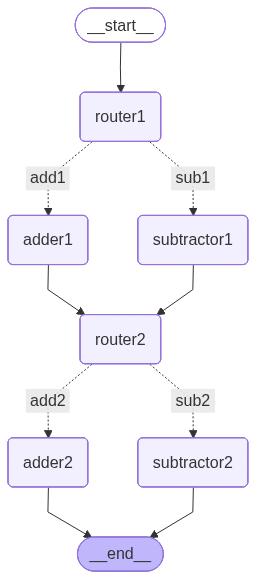

In [21]:
graph = StateGraph(AgentInput)

graph.add_node("adder1", adder1)
graph.add_node("subtractor1", subtractor1)
graph.add_node("adder2", adder2)
graph.add_node("subtractor2", subtractor2)
graph.add_node("router1", lambda state:state)
graph.add_node("router2", lambda state:state)
graph.add_edge(START, "router1")

# Conditional edges for operation1
graph.add_conditional_edges(
    "router1",
    choose_next_state_1,
    {
        "add1": "adder1",
        "sub1": "subtractor1"
    }
)

graph.add_edge("adder1", "router2")
graph.add_edge("subtractor1", "router2")

# Conditional edges for operation2
graph.add_conditional_edges(
    "router2",
    choose_next_state_2,
    {
        "add2": "adder2",
        "sub2": "subtractor2"
    }
)

graph.add_edge("adder2", END)
graph.add_edge("subtractor2", END)

bot = graph.compile()
bot

In [22]:
input_data = {
    "number1": "10",
    "number2": "5",
    "number3": "20",
    "number4": "8",
    "operation1": "+",
    "operation2": "-",
}
result = bot.invoke(input_data)
print(result)

{'number1': '10', 'number2': '5', 'number3': '20', 'number4': '8', 'operation1': '+', 'operation2': '-', 'result1': 15, 'result2': 12}
